<a href="https://colab.research.google.com/github/arunjthilak80/Data-Science-Projects/blob/main/IPL_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IPL Dataset

Step 1: Import pandas, matplotlib and seaborn libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Step 2: Load the datasets IPL Matches 2008-2020.csv and IPL Ball-by-Ball 2008-2020.csv

In [4]:
matches_df = pd.read_csv("/content/drive/MyDrive/IPL Dataset/IPL Matches 2008-2020.csv")
deliveries_df = pd.read_csv("/content/drive/MyDrive/IPL Dataset/IPL Ball-by-Ball 2008-2020.csv")

Step 3: Inspect dimensions and columns of the 2 csv files (Matches and Deliveries) attached

In [5]:
print("Matches Shape:", matches_df.shape)
print("Deliveries Shape:", deliveries_df.shape)

Matches Shape: (816, 17)
Deliveries Shape: (193468, 18)


Step 4: View data types and missing values

In [6]:
print("\n--- Matches Summary ---")
print(matches_df.info())




--- Matches Summary ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               816 non-null    int64  
 1   city             803 non-null    object 
 2   date             816 non-null    object 
 3   player_of_match  812 non-null    object 
 4   venue            816 non-null    object 
 5   neutral_venue    816 non-null    int64  
 6   team1            816 non-null    object 
 7   team2            816 non-null    object 
 8   toss_winner      816 non-null    object 
 9   toss_decision    816 non-null    object 
 10  winner           812 non-null    object 
 11  result           812 non-null    object 
 12  result_margin    799 non-null    float64
 13  eliminator       812 non-null    object 
 14  method           19 non-null     object 
 15  umpire1          816 non-null    object 
 16  umpire2          816 non-null    obje

In [7]:
print("Matches Info:", matches_df.info)
print("Deliveries Shape:", deliveries_df.info)

Matches Info: <bound method DataFrame.info of           id        city        date player_of_match  \
0     335982   Bangalore  2008-04-18     BB McCullum   
1     335983  Chandigarh  2008-04-19      MEK Hussey   
2     335984       Delhi  2008-04-19     MF Maharoof   
3     335985      Mumbai  2008-04-20      MV Boucher   
4     335986     Kolkata  2008-04-20       DJ Hussey   
..       ...         ...         ...             ...   
811  1216547       Dubai  2020-09-28  AB de Villiers   
812  1237177       Dubai  2020-11-05       JJ Bumrah   
813  1237178   Abu Dhabi  2020-11-06   KS Williamson   
814  1237180   Abu Dhabi  2020-11-08      MP Stoinis   
815  1237181       Dubai  2020-11-10        TA Boult   

                                          venue  neutral_venue  \
0                         M Chinnaswamy Stadium              0   
1    Punjab Cricket Association Stadium, Mohali              0   
2                              Feroz Shah Kotla              0   
3                

Step 5: Perform data cleansing and standardization

In [8]:
# Standardizing team names across both datasets
team_mappings = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Kings XI Punjab': 'Punjab Kings'
}

# Apply mappings to both DataFrames
for col in ['team1', 'team2', 'toss_winner', 'winner']:
    matches_df[col] = matches_df[col].replace(team_mappings)

deliveries_df['batting_team'] = deliveries_df['batting_team'].replace(team_mappings)
deliveries_df['bowling_team'] = deliveries_df['bowling_team'].replace(team_mappings)

# Convert the date column to a datetime object and extract Season
matches_df['date'] = pd.to_datetime(matches_df['date'])
matches_df['season'] = matches_df['date'].dt.year

print("Data Cleaning Complete. Missing values in winner filled:", matches_df['winner'].isnull().sum())

Data Cleaning Complete. Missing values in winner filled: 4


Step 6: High-Level (Match) Exploratory Analysis. Trying to find out which teams are the most successful and evaluate if winning the toss actually helps a team win the match.

/tmp/ipykernel_2954/1785656927.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='winner', data=matches_df, order=matches_df['winner'].value_counts().index, palette='viridis')


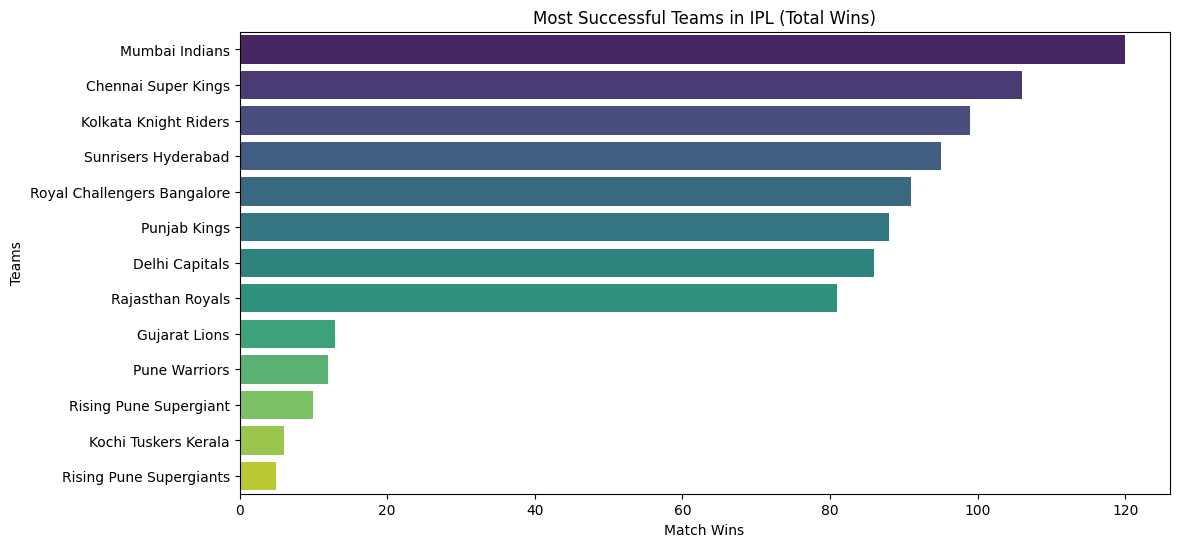

/tmp/ipykernel_2954/1785656927.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='toss_match_winner', data=matches_df, palette='Set2')


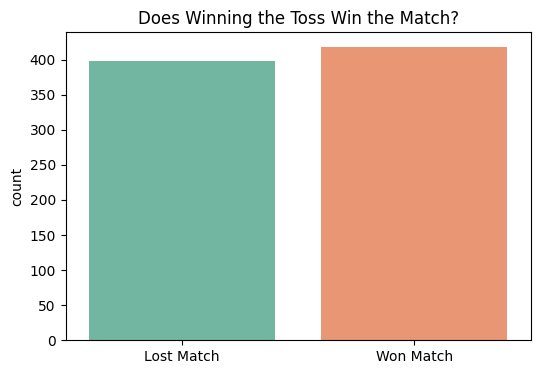

In [9]:
# 1. Total wins per team
plt.figure(figsize=(12, 6))
sns.countplot(y='winner', data=matches_df, order=matches_df['winner'].value_counts().index, palette='viridis')
plt.title('Most Successful Teams in IPL (Total Wins)')
plt.xlabel('Match Wins')
plt.ylabel('Teams')
plt.show()

# 2. Toss Decision Impact: Does winning the toss mean winning the match?
matches_df['toss_match_winner'] = (matches_df['toss_winner'] == matches_df['winner'])

plt.figure(figsize=(6, 4))
sns.countplot(x='toss_match_winner', data=matches_df, palette='Set2')
plt.title('Does Winning the Toss Win the Match?')
plt.xticks([0, 1], ['Lost Match', 'Won Match'])
plt.xlabel('')
plt.show()

Step 7: Perform Deep Dive Ball-by-Ball Analysis (Merging Data). To answer questions about player statistics (like top run-scorers), we need to compute metrics from the ball-by-ball delivery log.

NOTE:

(1) .groupby('batsman') segments our dataset by unique player names.

(2) .sum() then isolates the batsman_runs column and adds up every single run that individual player scored across all 13 years of data.

/tmp/ipykernel_2954/869903960.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_batsmen.values, y=top_batsmen.index, palette='magma')


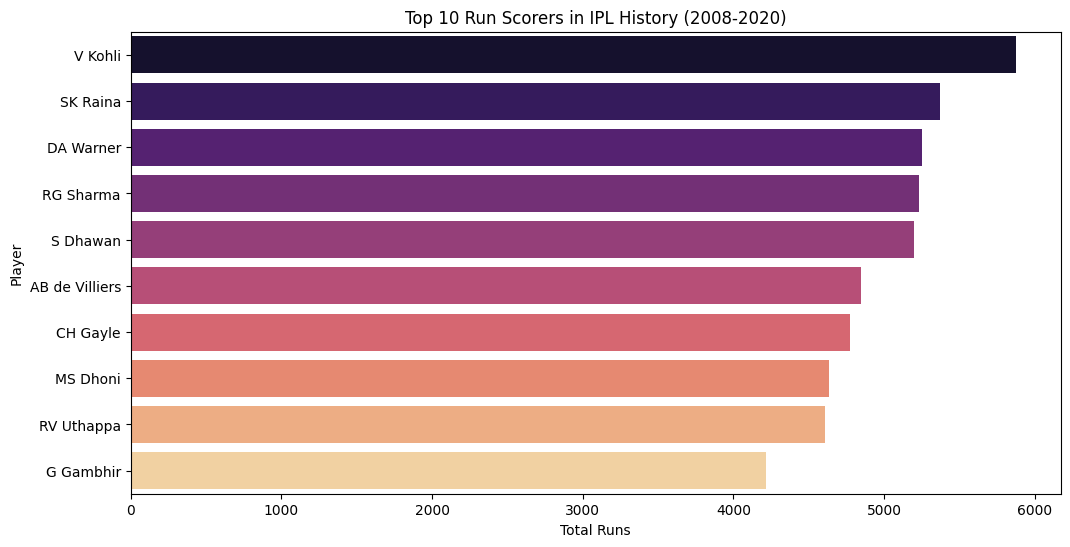

In [10]:
# Aggregate total runs scored by each batsman
top_batsmen = deliveries_df.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10)

# Plot top run scorers
plt.figure(figsize=(12, 6))
sns.barplot(x=top_batsmen.values, y=top_batsmen.index, palette='magma')
plt.title('Top 10 Run Scorers in IPL History (2008-2020)')
plt.xlabel('Total Runs')
plt.ylabel('Player')
plt.show()

Step 8: Advanced Cross-Dataset Aggregation. Trying to know how the average runs scored per match has changed across different seasons. To achieve this, we must link the season variable from our matches dataframe to our individual delivery entries.

NOTE:

(1) pd.merge(..., on='id', how='left') acts like a SQL JOIN or an advanced Excel VLOOKUP. It references the unique id to safely append contextual match details down to the delivery layer.

(2) sns.lineplot() maps continuous trends over an axis of time, helping you analyze shifts across operational cycles (seasons).

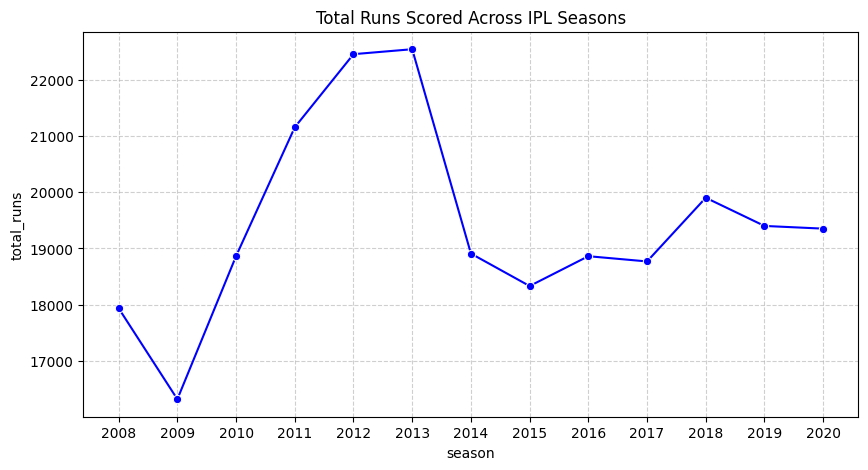

In [11]:
# Merge the 'season' column from matches into the deliveries dataframe using the unique 'id'
merged_df = pd.merge(deliveries_df, matches_df[['id', 'season']], on='id', how='left')

# Calculate total runs per season
runs_per_season = merged_df.groupby('season')['total_runs'].sum().reset_index()

# Plot seasonal progression
plt.figure(figsize=(10, 5))
sns.lineplot(x='season', y='total_runs', data=runs_per_season, marker='o', color='b')
plt.title('Total Runs Scored Across IPL Seasons')
plt.xticks(runs_per_season['season'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Step 9: Answering the Data Analysis questions one by one

Solving Q1, Q2 and Q3

1.	What was the count of matches played in each season?
2.	How many runs were scored in each season?
3.	What were the runs scored per match in different seasons?


--- Season-wise Statistical Analysis ---
        Total Matches  Total Runs  Average Runs Per Match
season                                                   
2008               58       17937              309.258621
2009               57       16320              286.315789
2010               60       18864              314.400000
2011               73       21154              289.780822
2012               74       22453              303.418919
2013               76       22541              296.592105
2014               60       18909              315.150000
2015               59       18332              310.711864
2016               60       18862              314.366667
2017               59       18769              318.118644
2018               60       19901              331.683333
2019               60       19400              323.333333
2020               60       19352              322.533333


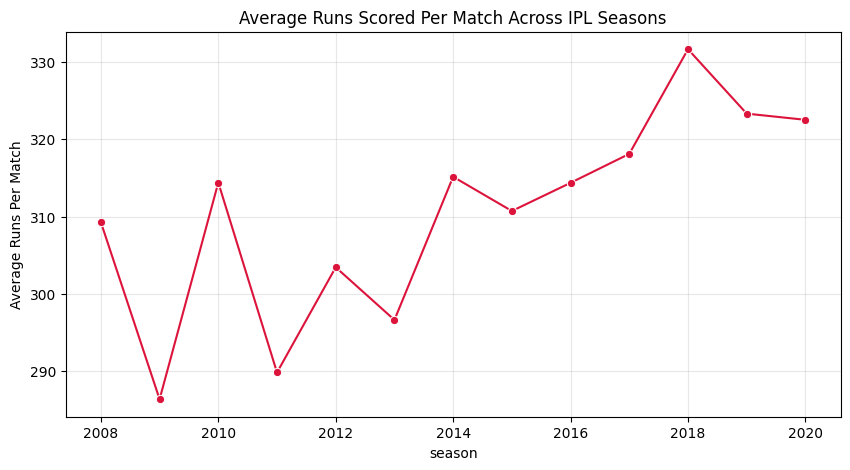

In [12]:
# 1. Count of matches played in each season
matches_per_season = matches_df['season'].value_counts().sort_index()

# 2. Total runs scored in each season
# First, merge 'season' from matches into deliveries
merged_df = pd.merge(deliveries_df, matches_df[['id', 'season']], on='id', how='left')
runs_per_season = merged_df.groupby('season')['total_runs'].sum()

# 3. Runs scored per match in different seasons
# Divide total runs by total matches for each season
runs_per_match_season = runs_per_season / matches_per_season

# Let's combine these insights into a clean summary table
season_summary = pd.DataFrame({
    'Total Matches': matches_per_season,
    'Total Runs': runs_per_season,
    'Average Runs Per Match': runs_per_match_season
})
print("--- Season-wise Statistical Analysis ---")
print(season_summary)

# Plotting the Average Runs Per Match over time
plt.figure(figsize=(10, 5))
sns.lineplot(data=season_summary, x=season_summary.index, y='Average Runs Per Match', marker='o', color='crimson')
plt.title('Average Runs Scored Per Match Across IPL Seasons')
plt.grid(True, alpha=0.3)
plt.show()

Solving Q4, Q5, Q6, Q7 and Q8

4.	Who has umpired the most?
5.	Which team has won the most tosses?
6.	What does the team decide after winning the toss?
7.	How does the toss decision vary across seasons?
8.	Does winning the toss imply winning the game?

NOTE:

(1) pd.concat() stacks umpire1 and umpire2 columns into a single collection so we don't miss an official's entry based on their field assignment position.

(2) value_counts(normalize=True) converts raw strategic frequency counts (bat vs field) into straightforward percentages.

(3) Comparing toss_winner == winner as a boolean sequence and taking its .mean() gives us the true historic win probability of winning the toss.


Top Umpire: S Ravi (121 matches)

Most Toss Wins: Mumbai Indians

Overall Toss Decisions Preference:
toss_decision
field    60.784314
bat      39.215686
Name: proportion, dtype: float64


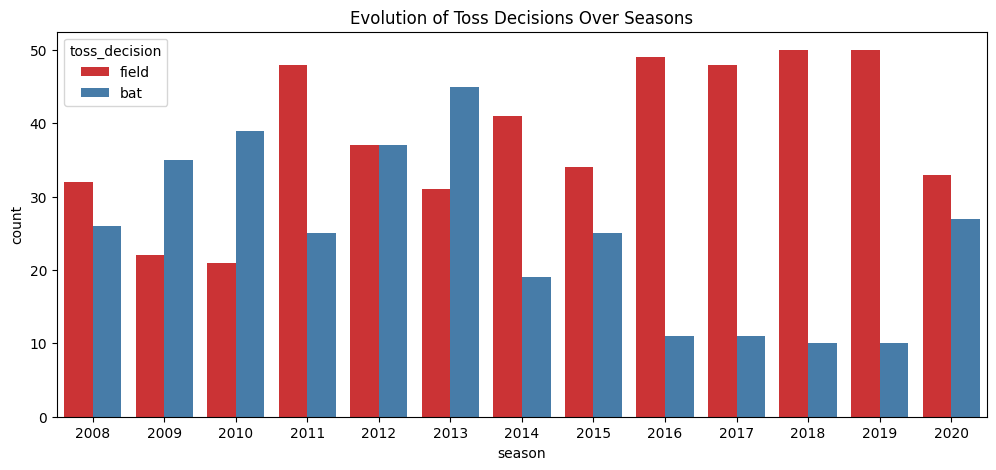


Percentage of times Toss Winner wins the Match: 51.23%


In [14]:
# 4. Who has umpired the most?
# Combine both umpire columns to get a true total count
all_umpires = pd.concat([matches_df['umpire1'], matches_df['umpire2']])
print(f"Top Umpire: {all_umpires.value_counts().idxmax()} ({all_umpires.value_counts().max()} matches)\n")

# 5. Which team has won the most tosses?
print(f"Most Toss Wins: {matches_df['toss_winner'].value_counts().idxmax()}\n")

# 6. What does the team decide after winning the toss?
print("Overall Toss Decisions Preference:")
print(matches_df['toss_decision'].value_counts(normalize=True) * 100)

# 7. How does the toss decision vary across seasons?
plt.figure(figsize=(12, 5))
sns.countplot(x='season', hue='toss_decision', data=matches_df, palette='Set1')
plt.title('Evolution of Toss Decisions Over Seasons')
plt.show()

# 8. Does winning the toss imply winning the game?
toss_match_win_pct = (matches_df['toss_winner'] == matches_df['winner']).mean() * 100
print(f"\nPercentage of times Toss Winner wins the Match: {toss_match_win_pct:.2f}%")

Solving Q9 to Q14

9.	How many times has the chasing team won the match?
10.	Which all teams had won this tournament?
11.	Which team has played the most number of matches?
12.	Which team has won the most number of times?
13.	Which team has the highest winning percentage?
14.	Is there any lucky venue for a particular team?

NOTE:

(1) .groupby('season').last() is a neat trick: since the matches are sorted by date, the last entry recorded for any given season is always the Final match.

(2) Adding team1 value counts to team2 value counts calculates the net operational footprint of each franchise, ensuring a proper denominator for the true historic win_percentage.

In [15]:
# 9. How many times has the chasing team won?
chasing_wins = matches_df[matches_df['result'] == 'wickets'].shape[0]
print(f"Total Chasing Wins (Batting Second): {chasing_wins} matches\n")

# 10. Which all teams had won this tournament?
# The tournament winner is the winner of the final match of each season
final_matches = matches_df.sort_values('date').groupby('season').last().reset_index()
champions = final_matches['winner'].value_counts()
print("--- IPL Champions Ledger ---")
print(champions)

# 11. Total matches played by each team (as team1 or team2)
matches_played = matches_df['team1'].value_counts() + matches_df['team2'].value_counts()
most_played = matches_played.idxmax()

# 12. Total wins per team
total_wins = matches_df['winner'].value_counts()

# 13. Highest winning percentage
win_percentage = (total_wins / matches_played * 100).sort_values(ascending=False)
print(f"\nTeam with highest win percentage: {win_percentage.idxmax()} ({win_percentage.max():.2f}%)")

# 14. Lucky venue for a particular team (Venues with > 5 wins where team has highest win ratio)
venue_wins = matches_df.groupby(['venue', 'winner']).size().unstack(fill_value=0)
lucky_venues = venue_wins.idxmax()
print("\n--- Top Winning Team for Select Major Venues ---")
print(lucky_venues.head(5))

Total Chasing Wins (Batting Second): 435 matches

--- IPL Champions Ledger ---
winner
Mumbai Indians           5
Chennai Super Kings      3
Sunrisers Hyderabad      2
Kolkata Knight Riders    2
Rajasthan Royals         1
Name: count, dtype: int64

Team with highest win percentage: Rising Pune Supergiant (62.50%)

--- Top Winning Team for Select Major Venues ---
winner
Chennai Super Kings             MA Chidambaram Stadium, Chepauk
Delhi Capitals                                 Feroz Shah Kotla
Gujarat Lions            Saurashtra Cricket Association Stadium
Kochi Tuskers Kerala                              Nehru Stadium
Kolkata Knight Riders                              Eden Gardens
dtype: object


Solving Q15 to Q19

15.	Innings wise comparison between teams
16.	Which team has scored the most number of 200+ scores?
17.	Which team has conceded 200+ scores the most?
18.	What was the highest run scored by a team in a single match?
19.	Which is the biggest win in terms of run margin?

NOTE:

(1) We first collapse the raw delivery log down to individual team totals (match_scores) using grouping metrics.

(2) .idxmax() locates the exact matrix index where peak values occur (highest scores, wider margins), giving us the record holders.

(3) By adding conditional columns (is_four, is_six), we can run .agg() to calculate total counts and instantly determine what percentage of total runs came from boundaries.


In [16]:
# Aggregate scores down to match innings level
match_scores = deliveries_df.groupby(['id', 'inning', 'batting_team', 'bowling_team'])['total_runs'].sum().reset_index()

# 15. Innings wise comparison
print("Average Runs Scored by Inning:")
print(match_scores.groupby('inning')['total_runs'].mean().head(2))

# 16 & 17. Most 200+ scores hit and conceded
scores_200 = match_scores[match_scores['total_runs'] >= 200]
print(f"\nMost 200+ Scores Scored: {scores_200['batting_team'].value_counts().idxmax()}")
print(f"Most 200+ Scores Conceded: {scores_200['bowling_team'].value_counts().idxmax()}")

# 18. Highest run scored by a team in a single match
highest_score_row = match_scores.loc[match_scores['total_runs'].idxmax()]
print(f"\nHighest Team Score: {highest_score_row['total_runs']} by {highest_score_row['batting_team']}")

# 19. Biggest win in terms of run margin
biggest_run_win = matches_df.loc[matches_df['result_margin'].idxmax()]
print(f"Biggest Win Margin: {biggest_run_win['result_margin']} runs achieved by {biggest_run_win['winner']}\n")

# Boundary Calculations across Seasons
merged_deliveries = pd.merge(deliveries_df, matches_df[['id', 'season']], on='id', how='left')
merged_deliveries['is_four'] = merged_deliveries['batsman_runs'] == 4
merged_deliveries['is_six'] = merged_deliveries['batsman_runs'] == 6

boundary_summary = merged_deliveries.groupby('season').agg(
    Fours_Count=('is_four', 'sum'),
    Sixes_Count=('is_six', 'sum'),
    Total_Season_Runs=('total_runs', 'sum')
).reset_index()

boundary_summary['Boundary_Runs'] = (boundary_summary['Fours_Count'] * 4) + (boundary_summary['Sixes_Count'] * 6)
boundary_summary['Contribution_Percentage'] = (boundary_summary['Boundary_Runs'] / boundary_summary['Total_Season_Runs']) * 100

print("--- Seasonal Boundary Dynamics ---")
print(boundary_summary[['season', 'Fours_Count', 'Sixes_Count', 'Contribution_Percentage']].head(5))


Average Runs Scored by Inning:
inning
1    161.932432
2    148.310811
Name: total_runs, dtype: float64

Most 200+ Scores Scored: Royal Challengers Bangalore
Most 200+ Scores Conceded: Punjab Kings

Highest Team Score: 263 by Royal Challengers Bangalore
Biggest Win Margin: 146.0 runs achieved by Mumbai Indians

--- Seasonal Boundary Dynamics ---
   season  Fours_Count  Sixes_Count  Contribution_Percentage
0    2008         1703          623                58.816971
1    2009         1317          506                50.882353
2    2010         1708          585                54.824003
3    2011         1916          639                54.353787
4    2012         1911          733                53.632031


Solving Q20 to Q27

20.	Which batsmen have played the most number of balls?
21.	Who are the leading run-scorers of all time?
22.	Who has hit the most number of 4's?
23.	Who has hit the most number of 6's?
24.	Who has the highest strike rate?
25.	Who is the leading wicket-taker?
26.	Which stadium has hosted the most number of matches?
27.	Who has won the most MOM awards?

NOTE:

(1) Wides do not count as a ball faced by a batsman, so we filter them out before calculating volume counts.

(2) For strike rates, filtering for a minimum threshold (>= 1000 balls faced) keeps the data clean by removing tail-end batsmen who might have an inflated strike rate from a few lucky hits.

(3) For bowler wickets, we carefully filter out dismissals like run out, since those points are not credited to the bowler's individual stats.


In [17]:
# 20. Most balls faced (excluding wides)
balls_faced = deliveries_df[deliveries_df['extras_type'] != 'wides']['batsman'].value_counts()

# 21. Leading run-scorers of all time
batsman_runs = deliveries_df.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False)

# 22 & 23. Most 4s and 6s
fours_lead = deliveries_df[deliveries_df['batsman_runs'] == 4]['batsman'].value_counts()
sixes_lead = deliveries_df[deliveries_df['batsman_runs'] == 6]['batsman'].value_counts()

# 24. Highest strike rate (Min 1000 balls faced to filter out outliers)
valid_batsmen = balls_faced[balls_faced >= 1000].index
sr_df = pd.DataFrame({'Runs': batsman_runs, 'Balls': balls_faced}).loc[valid_batsmen]
sr_df['Strike_Rate'] = (sr_df['Runs'] / sr_df['Balls']) * 100
highest_sr = sr_df['Strike_Rate'].sort_values(ascending=False)

print(f"All-Time Leading Run Scorer: {batsman_runs.index[0]} ({batsman_runs.iloc[0]} runs)")
print(f"Highest Strike Rate (>1000 balls): {highest_sr.index[0]} ({highest_sr.iloc[0]:.2f})\n")

# 25. Leading Wicket Taker
# Filter for bowler dismissals only (exclude run outs, retired hurt, etc.)
bowler_wickets = deliveries_df[deliveries_df['dismissal_kind'].isin(['caught', 'bowled', 'lbw', 'stumped', 'caught and bowled'])]
leading_bowler = bowler_wickets['bowler'].value_counts()
print(f"Leading Wicket Taker: {leading_bowler.index[0]} ({leading_bowler.iloc[0]} wickets)\n")

# 26 & 27. Top Stadium and MOM Awards
print(f"Stadium that hosted most matches: {matches_df['venue'].value_counts().idxmax()}")
print(f"Most Player of the Match (MOM) awards: {matches_df['player_of_match'].value_counts().idxmax()}")


All-Time Leading Run Scorer: V Kohli (5878 runs)
Highest Strike Rate (>1000 balls): V Sehwag (155.44)

Leading Wicket Taker: SL Malinga (170 wickets)

Stadium that hosted most matches: Eden Gardens
Most Player of the Match (MOM) awards: AB de Villiers


Solving Q32 to Q35

32.	Which team has scored the most runs in the first 6 overs?
33.	Which team has scored the most runs in the last 4 overs?
34.	Which team has the best scoring run-rate in the first 6 overs?
35.	Which team has the best scoring run-rate in the last 4 overs?

NOTE:

(1) In cricket datasets, indexing usually labels the 1st over as 0. Therefore, the Powerplay runs from 0 to 5, and the final death overs run from 16 to 19.

(2) To find the true scoring run-rate, we filter out illegal deliveries (like wides and no-balls) when counting the number of balls faced, ensuring our denominator matches real-world cricket rules.

In [18]:
# Filter segments: Powerplay (Overs 0 to 5 in python index), Death Overs (Overs 16 to 19)
powerplay_df = deliveries_df[deliveries_df['over'] < 6]
death_df = deliveries_df[deliveries_df['over'] >= 16]

# Helper function to compute runs and run rates efficiently
# Run Rate = (Total Runs / Total Balls) * 6
def calculate_phase_stats(df, phase_name):
    runs = df.groupby('batting_team')['total_runs'].sum()
    # Count balls (excluding wides/no-balls for accurate run rate calculation)
    balls = df[~df['extras_type'].isin(['wides', 'noballs'])].groupby('batting_team').size()

    stats = pd.DataFrame({'Total_Runs': runs, 'Balls_Faced': balls})
    stats['Run_Rate'] = (stats['Total_Runs'] / stats['Balls_Faced']) * 6
    return stats.sort_values(by='Run_Rate', ascending=False)

pp_stats = calculate_phase_stats(powerplay_df, "Powerplay")
death_stats = calculate_phase_stats(death_df, "Death Overs")

print("--- Top Team in Powerplay (First 6 Overs) ---")
print(f"Most Runs: {pp_stats['Total_Runs'].idxmax()} | Best Run Rate: {pp_stats['Run_Rate'].idxmax()} ({pp_stats['Run_Rate'].max():.2f})")

print("\n--- Top Team in Death Overs (Last 4 Overs) ---")
print(f"Most Runs: {death_stats['Total_Runs'].idxmax()} | Best Run Rate: {death_stats['Run_Rate'].idxmax()} ({death_stats['Run_Rate'].max():.2f})")


--- Top Team in Powerplay (First 6 Overs) ---
Most Runs: Sunrisers Hyderabad | Best Run Rate: Gujarat Lions (8.63)

--- Top Team in Death Overs (Last 4 Overs) ---
Most Runs: Mumbai Indians | Best Run Rate: Rising Pune Supergiants (10.85)


Solving Q28 to Q31

28.	What is the count of fours hit in each season?
29.	What is the count of sixes hit in each season?
30.	What is the count of runs scored from boundaries in each season?
31.	What is the run contribution from boundaries in each season?

NOTE:

(1) Date Parsing & Extraction: pd.to_datetime() converts string dates into datetime objects, and .dt.year pulls out the exact year (season) so that we can group data accurately across time.

(2) Left Join Merge: pd.merge(..., how='left') attaches the season information to every single ball delivery based on the common match id.

(3) Boundary Verification: We ensure non_boundary == 0 to filter out rare instances where batsmen ran 4 runs instead of hitting a boundary.

(4) Calculations: * Boundary Runs: Calculated using the formula: $\text{Boundary Runs} = (\text{Fours} \times 4) + (\text{Sixes} \times 6)$Contribution Percentage: Calculated using the formula: $\text{Contribution \%} = \left(\frac{\text{Boundary Runs}}{\text{Total Runs}}\right) \times 100$

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the datasets
matches_df = pd.read_csv("/content/drive/MyDrive/IPL Dataset/IPL Matches 2008-2020.csv")
deliveries_df = pd.read_csv("/content/drive/MyDrive/IPL Dataset/IPL Ball-by-Ball 2008-2020.csv")

# 2. Extract the 'season' column from the match dates
matches_df['date'] = pd.to_datetime(matches_df['date'])
matches_df['season'] = matches_df['date'].dt.year

# 3. Merge 'season' into the deliveries DataFrame using 'id'
merged_df = pd.merge(deliveries_df, matches_df[['id', 'season']], on='id', how='left')

# 4. Filter for legitimate boundaries (ignoring runs taken by running where non_boundary == 1)
merged_df['is_four'] = (merged_df['batsman_runs'] == 4) & (merged_df['non_boundary'] == 0)
merged_df['is_six'] = (merged_df['batsman_runs'] == 6) & (merged_df['non_boundary'] == 0)

# 5. Aggregate data by season
boundary_stats = merged_df.groupby('season').agg(
    Fours_Count=('is_four', 'sum'),
    Sixes_Count=('is_six', 'sum'),
    Total_Runs=('total_runs', 'sum')
).reset_index()

# 6. Compute runs scored from boundaries and percentage contribution
boundary_stats['Boundary_Runs'] = (boundary_stats['Fours_Count'] * 4) + (boundary_stats['Sixes_Count'] * 6)
boundary_stats['Contribution_Percentage'] = (boundary_stats['Boundary_Runs'] / boundary_stats['Total_Runs']) * 100

# Display the results
print("--- Seasonal Boundary Analysis Report ---")
print(boundary_stats.to_string(index=False))

--- Seasonal Boundary Analysis Report ---
 season  Fours_Count  Sixes_Count  Total_Runs  Boundary_Runs  Contribution_Percentage
   2008         1703          622       17937          10544                58.783520
   2009         1316          506       16320           8300                50.857843
   2010         1708          585       18864          10342                54.824003
   2011         1913          639       21154          11486                54.297060
   2012         1911          731       22453          12030                53.578586
   2013         2051          674       22541          12248                54.336542
   2014         1562          714       18909          10532                55.698345
   2015         1607          692       18332          10580                57.713288
   2016         1632          638       18862          10356                54.904040
   2017         1609          705       18769          10666                56.827748
   2018     